# Finding `coef_` and `intercept_` by hand

> 📘 **Instructor Curriculum** — M07 Machine Learning. Companion to
> [`05_Linear_Regression.ipynb`](./05_Linear_Regression.ipynb).

5 rows only, so every number can be checked on a calculator.
Written step by step by me, one cell at a time.


salary = m * years + c

m = coef_        how much salary rises per extra year
c = intercept_   the salary at 0 years


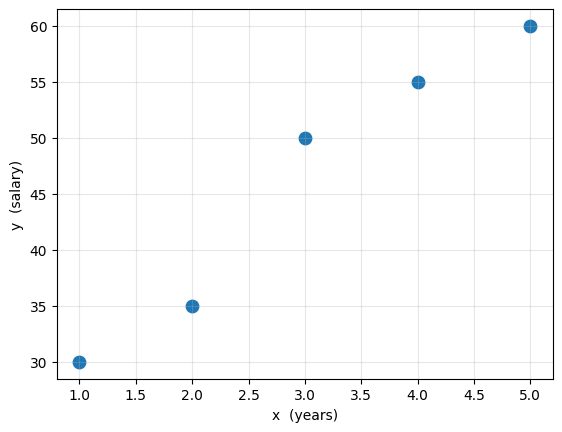

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([1, 2, 3, 4, 5])        # years of experience
y = np.array([30, 35, 50, 55, 60])   # salary in thousands

plt.scatter(x, y, s=80)
plt.xlabel("x  (years)")
plt.ylabel("y  (salary)")
plt.grid(alpha=0.3)
plt.show()


        sum of (each x − average x) × (each y − average y)
m  =   ────────────────────────────────────────────────────

              sum of (each x − average x) squared

c  =   average y  −  m × average x


average x = (1 + 2 + 3 + 4 + 5) / 5        = 15 / 5  = 3

average y = (30 + 35 + 50 + 55 + 60) / 5   = 230 / 5 = 46


In [2]:
x_bar = x.mean()
y_bar = y.mean()

print("average x =", x_bar)
print("average y =", y_bar)


average x = 3.0
average y = 46.0


x = 1  →  1 − 3  =  −2      2 years below average

x = 2  →  2 − 3  =  −1

x = 3  →  3 − 3  =   0      exactly average

x = 4  →  4 − 3  =   1

x = 5  →  5 − 3  =   2      2 years above average


In [3]:
x_diff = x - x_bar

print(x_diff)


[-2. -1.  0.  1.  2.]


y = 30  →  30 − 46  =  −16

y = 35  →  35 − 46  =  −11

y = 50  →  50 − 46  =    4

y = 55  →  55 − 46  =    9

y = 60  →  60 − 46  =   14


In [4]:
y_diff = y - y_bar

print(y_diff)


[-16. -11.   4.   9.  14.]


A:  (−2) × (−16)  =   32
B:  (−1) × (−11)  =   11
C:  ( 0) × (  4)  =    0
D:  ( 1) × (  9)  =    9
E:  ( 2) × ( 14)  =   28
                    ─────
              sum =   80     ← the TOP


In [5]:
products = x_diff * y_diff

print("each row :", products)
print("top      :", products.sum())


each row : [32. 11.  0.  9. 28.]
top      : 80.0


A:  (−2)²  =  4
B:  (−1)²  =  1
C:  ( 0)²  =  0
D:  ( 1)²  =  1
E:  ( 2)²  =  4
             ────
       sum = 10     ← the BOTTOM


In [6]:
squares = x_diff ** 2

print("each row :", squares)
print("bottom   :", squares.sum())


each row : [4. 1. 0. 1. 4.]
bottom   : 10.0


       80
m  =  ────  =  8
       10


In [7]:
m = products.sum() / squares.sum()

print("coef_ =", m)


coef_ = 8.0


      y  =  m × x  +  c
     46  =  8 × 3  +  c
     46  =    24   +  c
      c  =  46 − 24
      c  =  22


In [8]:
c = y_bar - m * x_bar

print("intercept_ =", c)
print()
print(f"our line:  y = {m} * x + {c}")


intercept_ = 22.0

our line:  y = 8.0 * x + 22.0


---

# Seeing it — the same numbers as pictures

Everything above was arithmetic. Below is the same thing drawn, so you can recognise it
without re-reading the code.

## The whole calculation as one map

```mermaid
flowchart TD
    A["the data<br/>x = 1, 2, 3, 4, 5<br/>y = 30, 35, 50, 55, 60"] --> B["the centre<br/>average x = 3<br/>average y = 46"]
    B --> C["column: x − 3<br/>−2, −1, 0, 1, 2"]
    B --> D["column: y − 46<br/>−16, −11, 4, 9, 14"]
    C --> E["multiply the two columns,<br/>then add<br/><b>TOP = 80</b>"]
    D --> E
    C --> F["square this column,<br/>then add<br/><b>BOTTOM = 10</b>"]
    E --> G["80 ÷ 10 = <b>8</b><br/>coef_"]
    F --> G
    G --> H["46 − 8 × 3 = <b>22</b><br/>intercept_"]
    B --> H
    H --> I["y = 8x + 22"]
    style E fill:#2f9e6f,color:#fff
    style F fill:#8a8f98,color:#fff
    style G fill:#2f6fed,color:#fff
    style H fill:#b3781f,color:#fff
    style I fill:#7a3f66,color:#fff
```

Read it once. Everything below is just one box of this map, drawn properly.

## Picture 1 — the TOP (80) is an **area**

Put the average point `(3, 46)` at the centre and draw the crosshairs through it. Every
dot now sits in one of four boxes.

For each dot, draw the rectangle between it and the centre. Its width is `x − 3`, its
height is `y − 46`, so **its area is exactly the product from Step 5**.

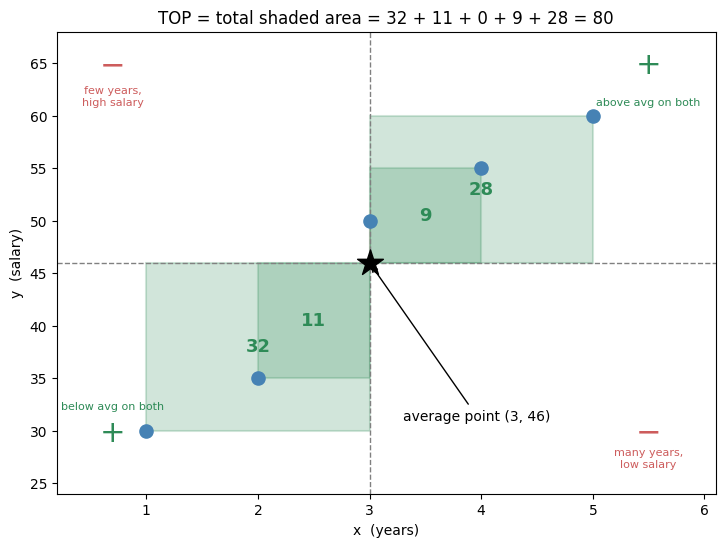

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 6))

# the crosshairs through the average point
ax.axvline(x_bar, color="grey", ls="--", lw=1)
ax.axhline(y_bar, color="grey", ls="--", lw=1)

# one rectangle per person: width = x - x̄, height = y - ȳ, area = the product
for xi, yi, p in zip(x, y, products):
    colour = "seagreen" if p > 0 else "indianred"
    ax.add_patch(plt.Rectangle((min(xi, x_bar), min(yi, y_bar)),
                               abs(xi - x_bar), abs(yi - y_bar),
                               facecolor=colour, alpha=0.22, edgecolor=colour, lw=1.5))
    if p != 0:
        ax.annotate(f"{p:.0f}", xy=((xi + x_bar) / 2, (yi + y_bar) / 2),
                    ha="center", va="center", fontsize=13, fontweight="bold", color=colour)

ax.scatter(x, y, s=90, color="steelblue", zorder=5)
ax.scatter([x_bar], [y_bar], marker="*", s=380, color="black", zorder=6)
ax.annotate("average point (3, 46)", xy=(x_bar, y_bar), xytext=(3.3, 31),
            arrowprops=dict(arrowstyle="->"))

# what each quadrant does to the total
ax.text(5.5, 64, "+", fontsize=22, color="seagreen", ha="center")
ax.text(0.7, 29, "+", fontsize=22, color="seagreen", ha="center")
ax.text(0.7, 64, "−", fontsize=22, color="indianred", ha="center")
ax.text(5.5, 29, "−", fontsize=22, color="indianred", ha="center")
ax.text(5.5, 61, "above avg on both", fontsize=8, color="seagreen", ha="center")
ax.text(0.7, 32, "below avg on both", fontsize=8, color="seagreen", ha="center")
ax.text(0.7, 61, "few years,\nhigh salary", fontsize=8, color="indianred", ha="center")
ax.text(5.5, 26.5, "many years,\nlow salary", fontsize=8, color="indianred", ha="center")

ax.set_xlim(0.2, 6.1); ax.set_ylim(24, 68)
ax.set_xlabel("x  (years)"); ax.set_ylabel("y  (salary)")
ax.set_title("TOP = total shaded area = 32 + 11 + 0 + 9 + 28 = 80")
plt.show()

**How to read it**

- Every rectangle here is **green**, because all 5 people are on the "agree" diagonal —
  more years really does go with more salary in this data.
- Person C sits exactly on the vertical line, so its rectangle has **zero width** and
  contributes `0`. Being average on x tells you nothing about the tilt.
- The two biggest rectangles are A and E — the people furthest from the centre. **Points
  far from the average count more.** That is not a flaw, it is the whole point: they are
  the ones that actually reveal the tilt.
- If one person had few years but a huge salary, their rectangle would land in a red box
  and be **subtracted**, dragging the total below 80 and flattening the line.

So `TOP = 80` is one sentence: *"how much do x and y agree, added up over everybody."*

## Picture 2 — the BOTTOM (10) is also an **area**, but it ignores salary

Same idea, one dimension. For each person take `x − 3` and draw a **real square** with
that side length. Its area is `(x − 3)²`.

Salary does not appear anywhere in this picture.

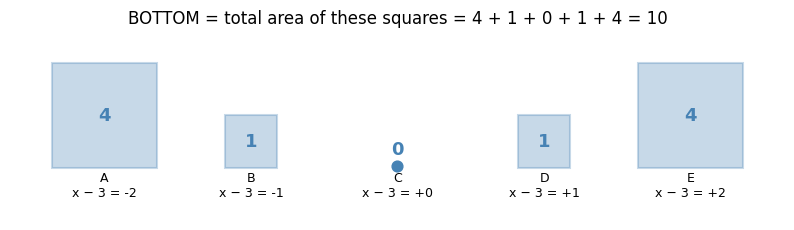

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.2))

slots = [0, 2.8, 5.6, 8.4, 11.2]          # one slot per person, spaced out
names = ["A", "B", "C", "D", "E"]

for slot, name, d, s in zip(slots, names, x_diff, squares):
    side = abs(d)
    if side > 0:
        ax.add_patch(plt.Rectangle((slot - side / 2, 0), side, side,
                                   facecolor="steelblue", alpha=0.3, edgecolor="steelblue", lw=1.5))
        ax.annotate(f"{s:.0f}", xy=(slot, side / 2), ha="center", va="center",
                    fontsize=13, fontweight="bold", color="steelblue")
    else:
        ax.scatter([slot], [0.03], color="steelblue", s=60)
        ax.annotate("0", xy=(slot, 0.25), ha="center", fontsize=13,
                    fontweight="bold", color="steelblue")
    ax.annotate(f"{name}\nx − 3 = {d:+.0f}", xy=(slot, -0.55), ha="center", fontsize=9)

ax.set_xlim(-1.8, 13); ax.set_ylim(-1.0, 2.6)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("BOTTOM = total area of these squares = 4 + 1 + 0 + 1 + 4 = 10")
plt.show()

**How to read it**

- Squaring is why `−2` and `+2` give the same square. Direction does not matter here,
  only **distance from the centre**.
- Person C has no square at all. Being exactly average contributes nothing.
- This number is the **spread of the years**, nothing more. Spread out people → big
  bottom. Clustered people → small bottom.

And the warning from Step 6 is now obvious: if all five people had 3 years, there would
be **no squares at all**, the bottom would be `0`, and dividing by it is impossible.

## Picture 3 — dividing is just cutting the 80 into 10 equal pieces

`coef_ = 80 ÷ 10`. Here is what that division means physically: take the agreement you
measured (80) and spread it evenly over the amount the years moved (10).

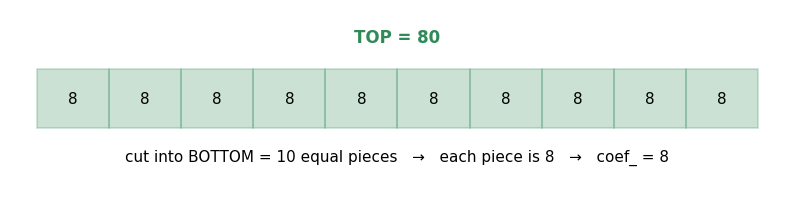

In [11]:
fig, ax = plt.subplots(figsize=(10, 2.4))

for k in range(10):
    ax.add_patch(plt.Rectangle((k * 8, 0), 8, 1, facecolor="seagreen",
                               alpha=0.25, edgecolor="seagreen", lw=1.2))
    ax.annotate("8", xy=(k * 8 + 4, 0.5), ha="center", va="center", fontsize=11)

ax.annotate("TOP = 80", xy=(40, 1.45), ha="center", fontsize=12, fontweight="bold", color="seagreen")
ax.annotate("cut into BOTTOM = 10 equal pieces   →   each piece is 8   →   coef_ = 8",
            xy=(40, -0.55), ha="center", fontsize=11)

ax.set_xlim(-3, 83); ax.set_ylim(-1.1, 2.0); ax.axis("off")
plt.show()

One piece = **8** = what one step of x is worth. It is the same shape as
`total distance ÷ total time = speed`.

## Picture 4 — the intercept is a **walk back to the y-axis**

`coef_` gave the tilt. Now the height.

The line is pinned by one rule: it must pass through the average point `(3, 46)`. So
stand there, and walk left to the y-axis. Each step back costs one year, and one year is
worth 8. Three steps back = 24 lost.

```text
46  −  8  −  8  −  8  =  22
```

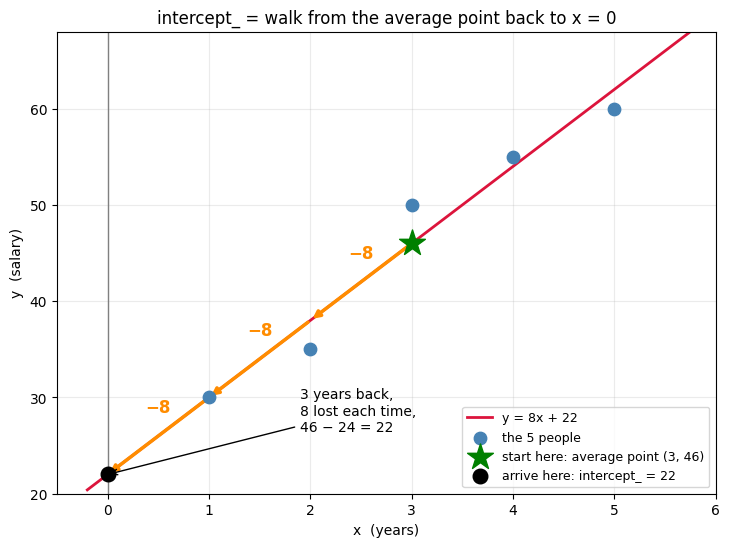

In [12]:
line_x = np.linspace(-0.2, 6, 50)

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(line_x, m * line_x + c, color="crimson", lw=2, label=f"y = {m:.0f}x + {c:.0f}")
ax.scatter(x, y, s=80, color="steelblue", zorder=5, label="the 5 people")

# three hops back along the line, from the average point to the y-axis
for step in range(3):
    x0 = x_bar - step
    ax.annotate("", xy=(x0 - 1, m * (x0 - 1) + c), xytext=(x0, m * x0 + c),
                arrowprops=dict(arrowstyle="-|>", color="darkorange", lw=2.5))
    ax.annotate("−8", xy=(x0 - 0.5, m * (x0 - 0.5) + c + 2.5),
                color="darkorange", ha="center", fontsize=12, fontweight="bold")

ax.scatter([x_bar], [y_bar], marker="*", s=380, color="green", zorder=6,
           label="start here: average point (3, 46)")
ax.scatter([0], [c], color="black", s=110, zorder=6, label=f"arrive here: intercept_ = {c:.0f}")

ax.axvline(0, color="grey", lw=1)
ax.annotate("3 years back,\n8 lost each time,\n46 − 24 = 22", xy=(0, c), xytext=(1.9, 26.5),
            arrowprops=dict(arrowstyle="->"), fontsize=10)

ax.set_xlim(-0.5, 6); ax.set_ylim(20, 68)
ax.set_xlabel("x  (years)"); ax.set_ylabel("y  (salary)")
ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.25)
ax.set_title("intercept_ = walk from the average point back to x = 0")
plt.show()

**How to read it**

- The green star is not decoration. **Every line this formula produces passes through the
  average point.** That is the rule that fixes the height.
- The three orange arrows are literally `46 − 8 − 8 − 8`.
- Change the tilt and the arrows get steeper, so the line lands somewhere else on the
  axis — which is why `intercept_` changes whenever `coef_` changes. The two numbers are
  not independent.

## One-page summary

| Picture | Number | Formula piece | In one sentence |
|---|---|---|---|
| green rectangles | **80** | $\sum (x-\bar{x})(y-\bar{y})$ | do x and y agree, added over everybody |
| blue squares | **10** | $\sum (x-\bar{x})^2$ | how spread out the years are, on their own |
| the 10 slices | **8** | `80 ÷ 10` → `coef_` | what one extra year is worth |
| the orange walk | **22** | $\bar{y} - m\bar{x}$ → `intercept_` | the height, found by walking back to x = 0 |

```text
             agreement          80
coef_   =  ───────────────  =  ────  =  8
            spread of x         10

intercept_ =  average y  −  coef_ × average x  =  46 − 24  =  22
```

## Key takeaway

**If you remember only one thing:** `fit()` does not search. It measures two areas — how
much x and y agree (80), and how much x moves on its own (10) — divides one by the other
to get the tilt, then slides the line so it passes through the average point.

Four columns, two sums, one division, one subtraction. That is the entire training of a
linear regression model.